In [43]:
from dotenv import load_dotenv
load_dotenv()

True

In [44]:
from langchain_community.document_loaders  import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import InMemoryVectorStore
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field

In [45]:
loader = PyPDFLoader("../data/sample-medical-report-lalpathLab.pdf")
docs = loader.load()

In [46]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
docs = splitter.split_documents(docs)

In [47]:
embed = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = InMemoryVectorStore.from_documents(documents=docs, embedding=embed)


In [48]:
class RagState(BaseModel):
    question: str = Field(description="User Question")
    documents: list = Field(default_factory=list, description="Retrieved documents")
    context: str = Field(default="", description="Context data for the user question")
    answer: str = Field(default="", description="Final answer")

In [49]:
llm = ChatGroq(model="openai/gpt-oss-20b")

def retrieve_node(state: RagState) -> RagState:
    question = state.question
    docs = vector_store.similarity_search(query=question, k=3)
    state.documents = docs
    return state

def create_context_node(state: RagState) -> RagState:
    context = ""
    for doc in state.documents:
        context += doc.page_content + "\n\n"
    state.context = context
    return state

def generate_node(state: RagState) -> RagState:
    prompt = f"""
    You are an assistant and provide the answer for the question based on the provided context.
    If you don't find the answer then just say 'I dont know'.

    Context is: {state.context}
    Question is: {state.question}
    """
    res = llm.invoke(prompt)
    state.answer = res.content
    return state

In [50]:
graph = StateGraph(RagState)
graph.add_node("retrieve", retrieve_node)
graph.add_node("create_context", create_context_node)
graph.add_node("generate", generate_node)

In [51]:
graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "create_context")
graph.add_edge("create_context", "generate")
graph.add_edge("generate", END)

rag_graph = graph.compile()

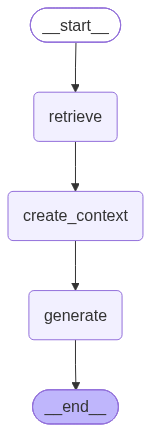

In [52]:
from IPython.display import Image
Image(rag_graph.get_graph().draw_mermaid_png())

In [53]:
res = rag_graph.invoke({'question':"What is the patient's name ?"})

In [54]:
print(res['answer'])


The patient's name is **DUMMY-9**
